<a href="https://colab.research.google.com/github/Aryan-Gupta2002/Deep-Learning---Tensorflow/blob/main/neuralNetworkForClassification_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###This notebook is to study about the classification models of Deep Learning with Neural Networks
------
**Classification is an algorithm which classifies which class a particular sample belongs to.** (eg: if an email belongs to Spam class or Not Spam Class)  
Types of Classification:-   
•Binary Classification  
•Multiclass Classification  
•Multilabel Classification

###Basic Architecture of Classification Model
----
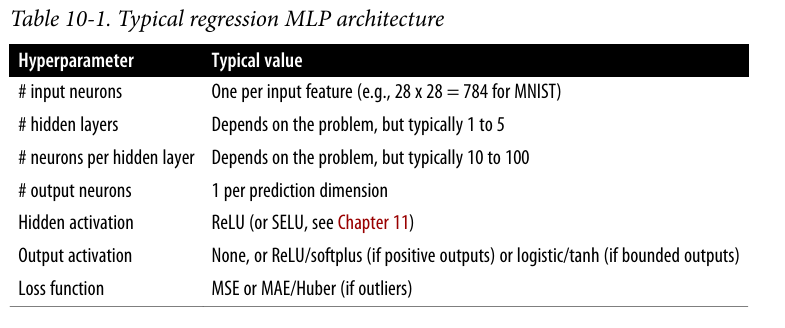


#Creating Dataset to view and fit

In [ ]:
from sklearn.datasets import make_circles
# Making 1000 samples
n_samples = 1000

# Creating Circles
x,y=make_circles(n_samples,
                 noise=0.03,
                 random_state=42)

In [ ]:
# Checking out features and labels
x,y[:10]

(array([[ 0.75424625,  0.23148074],
        [-0.75615888,  0.15325888],
        [-0.81539193,  0.17328203],
        ...,
        [-0.13690036, -0.81001183],
        [ 0.67036156, -0.76750154],
        [ 0.28105665,  0.96382443]]),
 array([1, 1, 1, 1, 0, 1, 1, 1, 1, 0]))

Our data is little hard to understand, let's visualize it

In [ ]:
import pandas as pd
circles = pd.DataFrame({"X0":x[:,0],"X1":x[:,1],"labels":y})
circles

,X0,X1,labels
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
...,...,...,...
995,0.244054,0.944125,0
996,-0.978655,-0.272373,0
997,-0.136900,-0.810012,1
998,0.670362,-0.767502,0


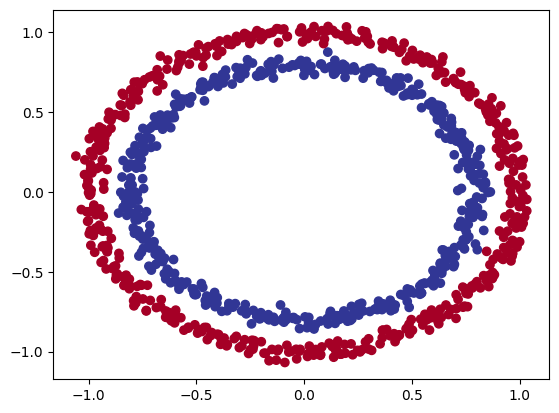

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(x[:,0],x[:,1],c=y, cmap=plt.cm.RdYlBu)

In [ ]:
# checking shapes of our features and labels
x.shape,y.shape,len(x),len(y)

((1000, 2), (1000,), 1000, 1000)

## Steps in Modelling
----
1.Create or import a model  
2.Compile the model  
3.Fit the model  
4.Evaluate the model  
5.Tweak  
6.Evaluate

In [ ]:
import tensorflow as tf

2026-02-17 18:31:26.560960: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771353086.756761      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771353086.813844      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771353087.284843      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771353087.284900      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771353087.284904      55 computation_placer.cc:177] computation placer alr

In [ ]:
#Setting seed
tf.random.set_seed(42)
# Model Building
model_1=tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])
# Compiling Model
model_1.compile(
    loss = tf.keras.losses.BinaryCrossentropy,
    optimizer = tf.keras.optimizers.SGD(),
    metrics=["accuracy"]
)
#Fitting with data
model_1.fit(x,y,epochs=5)


Epoch 1/5


2026-02-17 18:31:38.939835: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4467 - loss: 5.9466   
Epoch 2/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4439 - loss: 4.7192 
Epoch 3/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4921 - loss: 2.1790 
Epoch 4/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4622 - loss: 0.7067 
Epoch 5/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5068 - loss: 0.6951 


In [ ]:
# Let's try to improve our model
model_1.fit(x,y,epochs=5,verbose=0)
model_1.evaluate(x,y) # it is not right to evaluate on same traininig data

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4498 - loss: 0.6928 


[0.6932570338249207, 0.44699999690055847]

Since we're working on a binary classification problem and our model is getting around 50% accuracy. It's basically guessing and not actually learning

In [ ]:
# Let's try adding an extra layer
tf.random.set_seed(42)
model2 = tf.keras.Sequential([
    tf.keras.layers.Dense(1),
    tf.keras.layers.Dense(1),
])
model2.compile(
    loss = tf.keras.losses.BinaryCrossentropy,
    optimizer=tf.keras.optimizers.SGD(),
    metrics=["accuracy"]
)
model2.fit(x,y,epochs=200,verbose=0)
model2.evaluate(x,y) # not much happened, results are similar

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4955 - loss: 0.6932 


[0.6931995153427124, 0.5]

## Improving the model  
We can do perform follwing updates to check if our model improves   
1. Create a model - we might add layers or increase the number of hidden units within a layer  
2. Compiling a model - here we might choose a different optimization function such as ADAM instead of SGD    
3. Fitting a model- perhaps we might fit our model for more epochs for longer learning period


In [ ]:
# This time let's try to add one exrtra layer with more neurons.
tf.random.set_seed(42)
model3 = tf.keras.Sequential([
    tf.keras.layers.Dense(100),
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1),
])
model3.compile(
    loss=tf.keras.losses.BinaryCrossentropy,
    optimizer=tf.keras.optimizers.Adam(),
    metrics=["accuracy"]
)
model3.fit(x,y,epochs=200,verbose=0)


In [ ]:
model3.evaluate(x,y)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4995 - loss: 0.6917  


[0.6943394541740417, 0.48399999737739563]

At this point we can notice that the model is not improving at all. The adjustment of the above hyperparameters seemed to work in case of regression model training

To Visualize our model's prediction , let's create a function **"plot_decision-boundary"**,this function will:   

*Take in a trained model, feature (x) and labels (y)  
*Create a meshgrid of the different x values   
*Make predictions across the meshgrid  
*Plot the predictions as well as a line between zones (where each unique class falls)  
**NOTE:** Study about Meshgrid    
link-https://www.geeksforgeeks.org/python/numpy-meshgrid-function/

In [ ]:
import numpy as np

Resource: https://cs231n.github.io/

In [ ]:
def plot_decision_boundary(model,x,y):
  """Plot the decision boundary created by a model predicting on X"""
  #Define the axis boundaries of the plot and create a meshgrid
  x_min,x_max = x[:,0].min()-0.1,x[:,0].max()+0.1
  y_min,y_max=x[:,1].min()-0.1,x[:,1].max()+0.1
  xx,yy=np.meshgrid(np.linspace(x_min,x_max,100),
                    np.linspace(y_min,y_max,100))

  #Create x value (we're going to make predictions on these)
  x_in = np.c_[(xx.ravel(),yy.ravel())] # stack 2D arrays together

  #Make predictions
  y_pred = model.predict(x_in)

  #Check for multi-class
  if len(y_pred[0])>1:
    print("doing multiclass classification")
    # We have to reshape our predictions to get them ready for plotting
    y_pred = np.argmax(y_pred,axis=1).reshape(xx.shape)
  else:
    print("Doing binary classification")
    y_pred = np.round(y_pred).reshape(xx.shape)

  # Plot the decision boundary
  plt.contourf(xx,yy,y_pred,cmap=plt.cm.RdYlBu,alpha=0.7)
  plt.scatter(x[:,0],x[:,1],c=y,s=40,cmap=plt.cm.RdYlBu)
  plt.xlim(xx.min(),xx.max())
  plt.ylim(yy.min(),yy.max())

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 797us/step
Doing binary classification


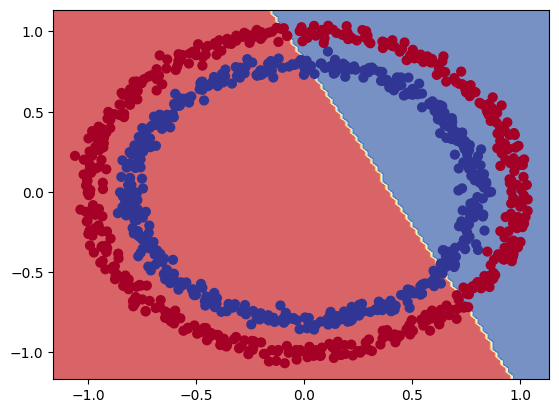

In [ ]:
# Let's try decision boundary
plot_decision_boundary(model3,x,y)

Explanation  : So our model3 is trained and put to set with our classification dataset. The model3 is a linear model which draws a line to predict the outputs. However, in our current dataset, we have two circles, one inside another, and our model is trying to plot a line with least loss. However, a straight line model cannot classify and perform well on our current dataset.

In [ ]:
# Let's try the model for regression model
x_reg = tf.range(0,1000,5)
x_reg = tf.expand_dims(x_reg, axis=-1)
y_reg = tf.range(100,1100,5)


#Splitting
x_reg_train= x_reg[:150]
x_reg_test = x_reg[150:]
y_reg_train= y_reg[:150]
y_reg_test = y_reg[150:]


In [ ]:
x_reg_train.shape,y_reg_train.shape

(TensorShape([150, 1]), TensorShape([150]))

In [ ]:
tf.random.set_seed(42)
model3= tf.keras.Sequential([
    tf.keras.layers.Dense(100),
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1),
])
model3.compile(
    loss= tf.keras.losses.mae,
    optimizer=tf.keras.optimizers.Adam(),
    metrics=["mae"]
)
model3.fit(x_reg_train,y_reg_train,epochs=100)
model3.evaluate(x_reg_test,y_reg_test)

Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 339.9081 - mae: 339.9081  
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 195.5247 - mae: 195.5247 
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 62.6597 - mae: 62.6597 
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 82.0786 - mae: 82.0786 
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 80.2262 - mae: 80.2262 
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 47.0636 - mae: 47.0636 
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 52.8553 - mae: 52.8553 
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 40.5935 - mae: 40.5935 
Epoch 9/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 46.8817 - mae: 46.8817 
Epoch 10/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 41.2954 - mae: 41.2954 
Epoch 11/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 42.4285 - mae: 42.4285 
Epoch 12/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 39.9035 - mae: 39.9035 
Epoch 13/100
5/5 ━━━

[52.53156280517578, 52.53156280517578]

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


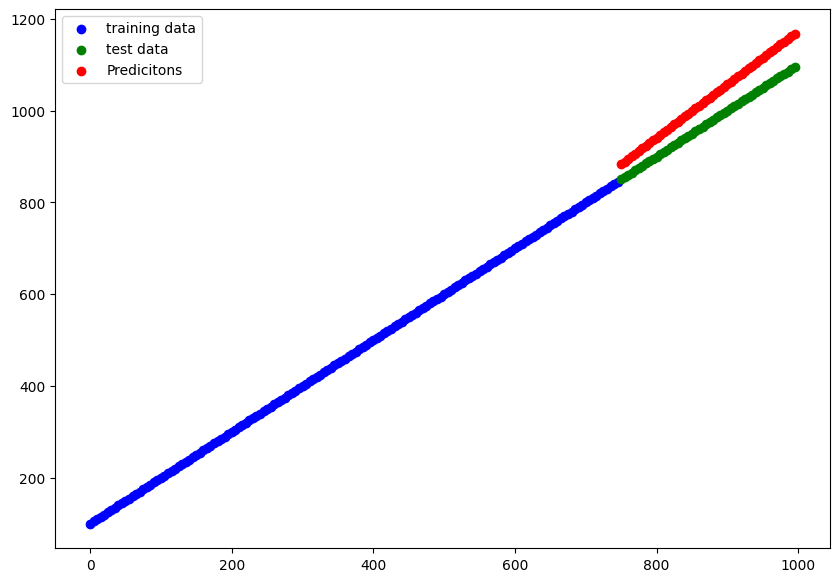

In [ ]:
y_reg_pred=model3.predict(x_reg_test) # PRedictions

#Plotting model's predictions
plt.figure(figsize=(10,7))
plt.scatter(x_reg_train,y_reg_train, c='b', label="training data")
plt.scatter(x_reg_test,y_reg_test,c='g',label="test data")
plt.scatter(x_reg_test,y_reg_pred,c='r',label="Predicitons")
plt.legend();

#ReLU (Rectified Linear Unit) is defined as:

𝑓(𝑥)=max(0,𝑥)  
f(x)=max(0,x)

That means:

if
𝑥
<
0
x<0 → output = 0

if
𝑥
≥
0
x≥0 → output = x

##Adding Non-linearity to a linearly inseparable dataset.  
Non-linear activations- Relu, Sigmoid, Tan

In [ ]:
x.shape,y.shape

((1000, 2), (1000,))

In [ ]:
#Using Relu non-linear activation for our dataset
tf.random.set_seed(42)
model4 = tf.keras.Sequential([
    tf.keras.layers.Dense(4,activation="relu"),
    tf.keras.layers.Dense(4,activation="relu"),
    tf.keras.layers.Dense(1),
])
model4.compile(
    loss = "binary_crossentropy",
    optimizer=tf.keras.optimizers.Adam(),
    metrics=["accuracy"]
)
history = model4.fit(x,y,epochs=100)

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4830 - loss: 8.3336
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4830 - loss: 8.3336 
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4830 - loss: 8.3336 
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4830 - loss: 8.3336 
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4830 - loss: 8.3336 
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4830 - loss: 8.3336 
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4830 - loss: 8.3336 
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4830 - loss: 8.3336 
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4830 - loss: 8.3336 
Epoch 10/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4830 - loss: 8.3336 
Epoch 11/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4830 - loss: 8.3336 
Epoch 12/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step -

In [ ]:
model4.evaluate(x,y)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4955 - loss: 8.1322   


[8.059046745300293, 0.5]

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 774us/step
Doing binary classification


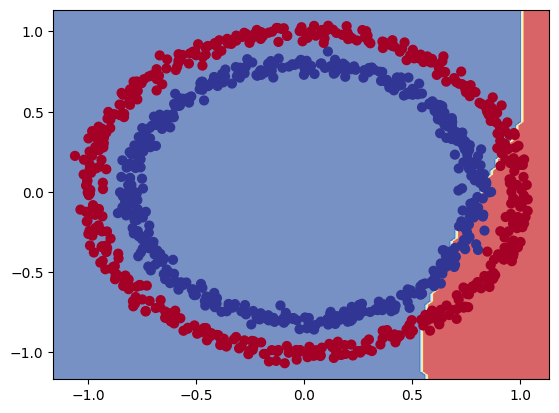

In [ ]:
plot_decision_boundary(model4,x,y)

### Our model did not perform good above but we have not yet tried output layer activation.   
### Let's try sigmoid (for binary classification) as output layer activation. Softmax( for multi class classification)

In [ ]:
#Using Relu non-linear activation for our dataset
tf.random.set_seed(42)
model4 = tf.keras.Sequential([
    tf.keras.layers.Dense(4,activation="relu"),
    tf.keras.layers.Dense(4,activation="relu"),
    tf.keras.layers.Dense(1,activation ="sigmoid")
])
model4.compile(
    loss = "binary_crossentropy",
    optimizer=tf.keras.optimizers.Adam(),
    metrics=["accuracy"]
)
history = model4.fit(x,y,epochs=100)

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5037 - loss: 0.6978   
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5036 - loss: 0.6969 
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5025 - loss: 0.6966 
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5056 - loss: 0.6963 
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4821 - loss: 0.6960 
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4834 - loss: 0.6958 
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4872 - loss: 0.6955
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4895 - loss: 0.6953
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4815 - loss: 0.6951 
Epoch 10/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4780 - loss: 0.6949 
Epoch 11/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4853 - loss: 0.6947 
Epoch 12/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 

In [ ]:
model4.evaluate(x,y)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9535 - loss: 0.3448  


[0.3405532240867615, 0.9610000252723694]

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 815us/step
Doing binary classification


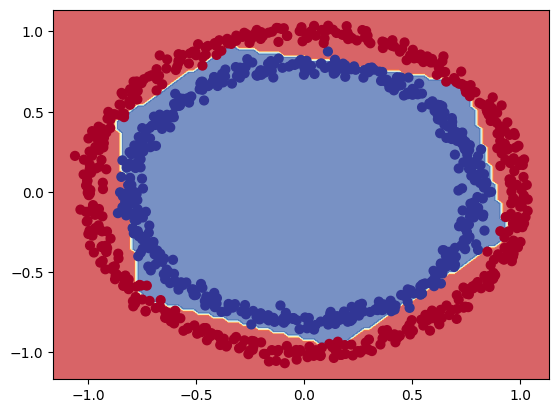

In [ ]:
plot_decision_boundary(model4,x,y)

A sigmoid is an activation function which takes in inputs and return 0 or 1 as output, that is why is used for binary classification.   
Now we will convert a straight line to a non-linear using sigmoid

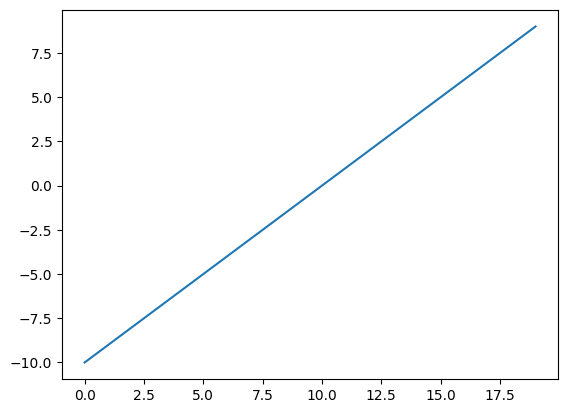

In [ ]:
A = tf.cast(tf.range(-10,10), tf.float32)
plt.plot(A)

In [ ]:
def sigmoid(x):
    return 1/(1+tf.exp(-x))
sigmoid(A)

<tf.Tensor: shape=(20,), dtype=float32, numpy=
array([4.5397872e-05, 1.2339458e-04, 3.3535014e-04, 9.1105117e-04,
       2.4726233e-03, 6.6928510e-03, 1.7986210e-02, 4.7425874e-02,
       1.1920292e-01, 2.6894143e-01, 5.0000000e-01, 7.3105860e-01,
       8.8079703e-01, 9.5257413e-01, 9.8201376e-01, 9.9330717e-01,
       9.9752742e-01, 9.9908900e-01, 9.9966466e-01, 9.9987662e-01],
      dtype=float32)>

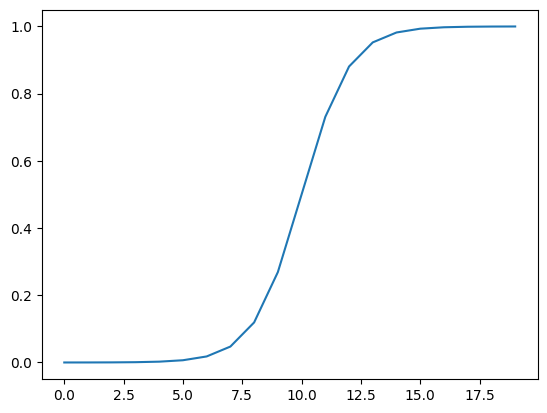

In [ ]:
plt.plot(sigmoid(A))

In [ ]:
# Creating relu function
def relu(x):
    return tf.maximum(0,x)
relu(A)

<tf.Tensor: shape=(20,), dtype=float32, numpy=
array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 2., 3., 4., 5., 6.,
       7., 8., 9.], dtype=float32)>

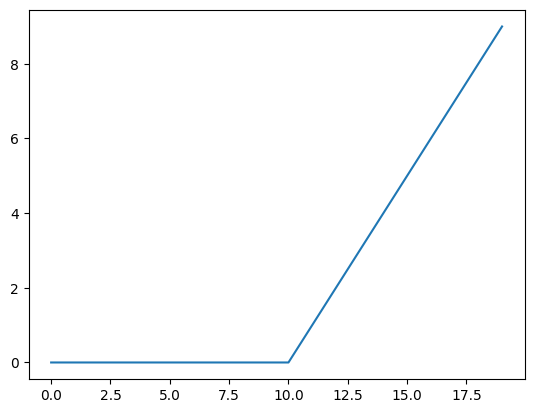

In [ ]:
plt.plot(relu(A))

In [ ]:
len(x)

1000

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x_train,x_test,y_train,y_test= train_test_split(x,y,test_size=0.2,random_state=42)
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((800, 2), (200, 2), (800,), (200,))

In [ ]:
# This time let's see the effect of learning rate on our model
model5 = tf.keras.Sequential([
    tf.keras.layers.Dense(4,activation="relu"),
    tf.keras.layers.Dense(4,activation="relu"),
    tf.keras.layers.Dense(1,activation="sigmoid")
])
model5.compile(
    loss="binary_crossentropy",
    optimizer=tf.keras.optimizers.Adam(learning_rate = 0.01),
    metrics=["accuracy"]
)
history3 = model5.fit(x,y,epochs= 25)

Epoch 1/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5085 - loss: 0.6919   
Epoch 2/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5168 - loss: 0.6893 
Epoch 3/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5191 - loss: 0.6879 
Epoch 4/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5215 - loss: 0.6857 
Epoch 5/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5387 - loss: 0.6826 
Epoch 6/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5391 - loss: 0.6782 
Epoch 7/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5380 - loss: 0.6651 
Epoch 8/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6147 - loss: 0.6437 
Epoch 9/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6715 - loss: 0.6161 
Epoch 10/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7020 - loss: 0.5862 
Epoch 11/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7588 - loss: 0.5327 
Epoch 12/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy

In [ ]:
model5.evaluate(x_test,y_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9818 - loss: 0.1252  


[0.1277592033147812, 0.9800000190734863]

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 818us/step
Doing binary classification
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 749us/step
Doing binary classification


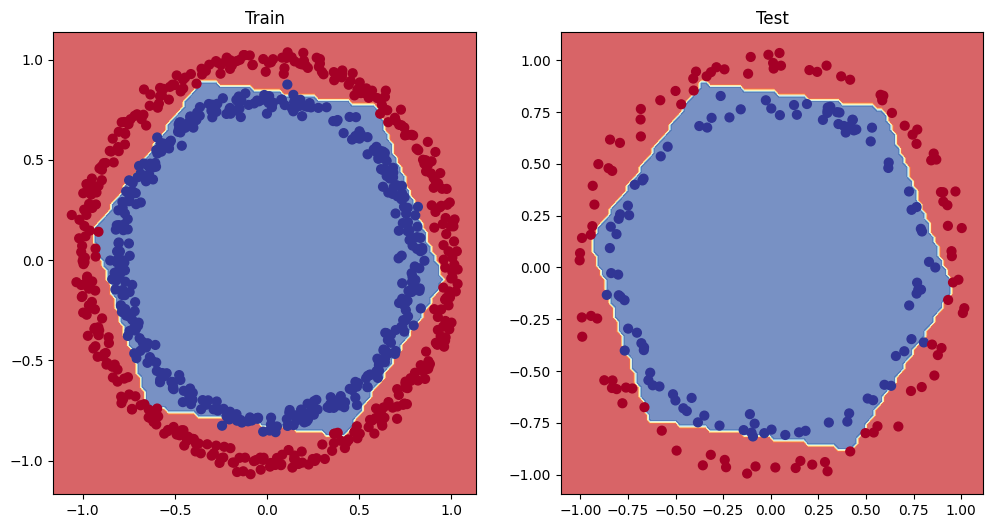

In [ ]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model5,x_train,y_train)
plt.subplot(1,2,2)   # Keep indexing in mind
plt.title("Test")
plot_decision_boundary(model5,x_test,y_test)
plt.show()